# **Capítulo 4: Transformada de Fourier de Señales periódicas y aperiódicas**

```
 Libro:  Analisis de Señales Utilizando Python
```


**Autor:  Dora María Ballesteros Larrotta**  
Universidad Militar Nueva Granada (UMNG)

---

### Material complementario del libro

Este notebook acompaña el **Capítulo 4** y contiene los ejemplos desarrollados a lo largo del texto. Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.


# **Ejemplo 32. TF de suma de señales cosenoidales**

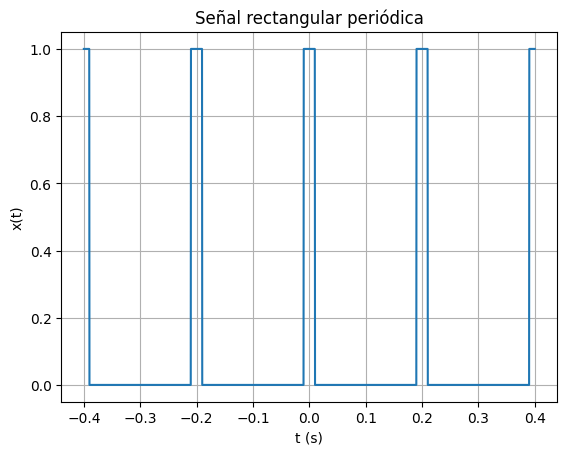

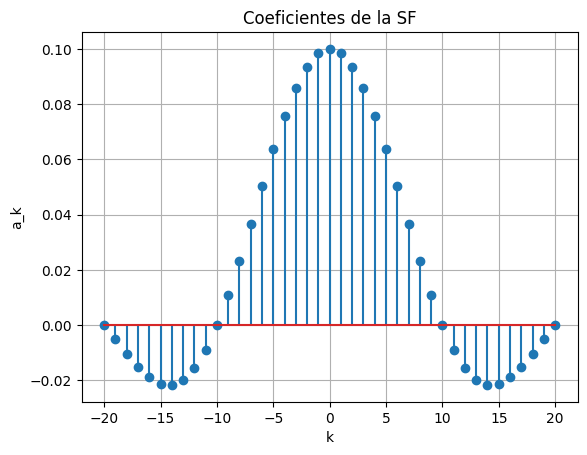

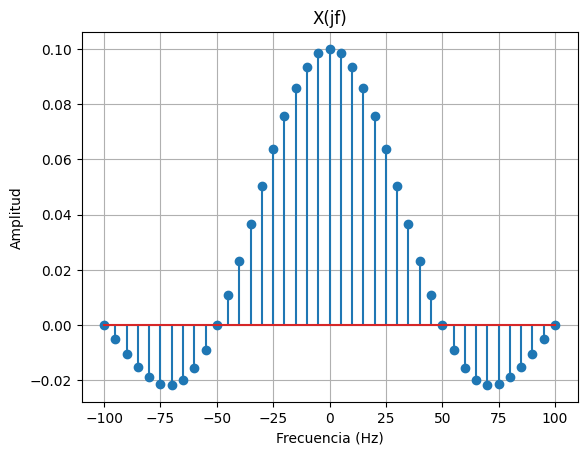

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del ejemplo
T1 = 0.01
T = 20*T1
f0 = 1/T

# 1. Señal rectangular periódica
t = np.linspace(-2*T,2*T,2000)
x = np.zeros_like(t)

for n in range(-3,4):
    x[(t>=-T1+n*T) & (t<=T1+n*T)] = 1

plt.figure(); plt.plot(t,x)
plt.title("Señal rectangular periódica")
plt.xlabel("t (s)"); plt.ylabel("x(t)")
plt.grid(); plt.show()

# 2. Coeficientes de Fourier
k = np.arange(-20,21)
ak = np.zeros(len(k))

for i,ki in enumerate(k):
    if ki==0:
        ak[i] = 2*T1/T
    else:
        ak[i] = np.sin(ki*np.pi/10)/(ki*np.pi)

plt.figure(); plt.stem(k,ak)
plt.title("Coeficientes de la SF")
plt.xlabel("k"); plt.ylabel("a_k")
plt.grid(); plt.show()

# 3. Espectro X(jf)
f = k*f0

plt.figure(); plt.stem(f,ak)
plt.title("X(jf)"); plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.grid(); plt.show()

# **Ejemplo 43. Análisis espectral señal de voz con ruido externo tipo tono**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from IPython.display import Audio, display

# =========================
# 1. Cargar archivo de audio
# =========================
audio_path = "audio.wav"   # Cambia por el nombre o la ruta de tu archivo
x, fs = librosa.load(audio_path, sr=None)

print("frecuencia de muestro del audio:", fs)

# =========================
# 2. Reproducir audio
# =========================
display(Audio(x, rate=fs))


frecuencia de muestro del audio: 8000


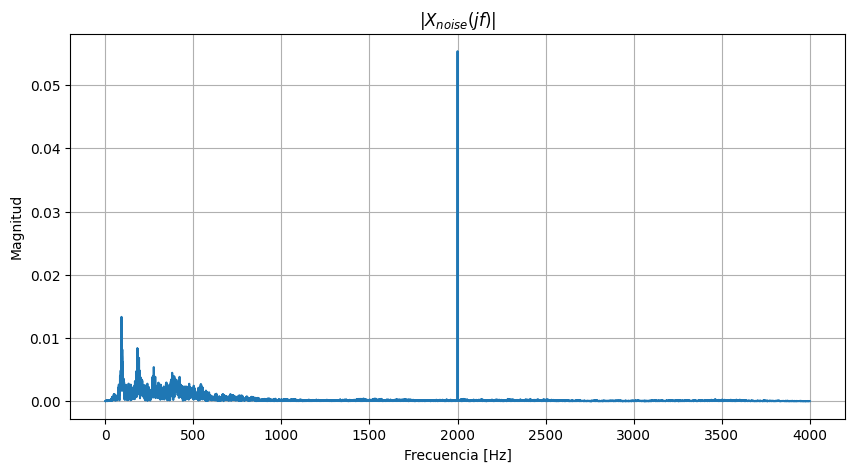

In [ ]:
# =========================
# 3. Calcular la FFT
# =========================
N = len(x)                          # Número de muestras
X = np.fft.fft(x)                   # Transformada de Fourier
f = np.fft.fftfreq(N, d=1/fs)       # Vector de frecuencias

# =========================
# 4. Tomar solo frecuencias positivas
# =========================
mask = f >= 0
f_pos = f[mask]
X_pos = X[mask]

# =========================
# 5. Magnitud del espectro
# =========================
X_mag = np.abs(X_pos) / N

# =========================
# 6. Graficar espectro
# =========================
plt.figure(figsize=(10, 5))
plt.plot(f_pos, X_mag)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title(r"$|X_{noise}(jf)|$")

plt.grid(True)
plt.show()

Libro: Analisis de Señales Utilizando Python

---


Versión: 2026 – Material complementario para Google Colab.